# Unfreeze classifier + layer 10 + layer 11 dan sudah Format BIO (NER)

# Install & import library

In [1]:
!pip install -q transformers datasets accelerate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.0 MB/s eta 0:00:00
E

In [2]:
import os
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch

from datasets import Dataset, DatasetDict, Features, Sequence, Value
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

2025-11-30 12:08:28.936593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764504509.140253      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764504509.194050      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Load file TSV dan tampilkan ringkasan

In [3]:
# Load dataset (token per line)
if os.path.exists('/kaggle/input'):
    path = "/kaggle/input/datasetsinggalang/SINGGALANG_oversampled.tsv"
else:
    path = "./data/SINGGALANG_oversampled.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    header=None,
    skiprows=[0],  # hapus skiprows  file  punya header
    names=["token", "label"],
    dtype=str,
    keep_default_na=False
)

print("Total baris (token):", len(df))
print(df.head(20))


Total baris (token): 5360092
          token  label
0            Ia      O
1      menjabat      O
2       sebagai      O
3      Presiden      O
4        ketiga      O
5         Mesir  Place
6          pada      O
7       periode      O
8            15      O
9       Oktober      O
10         1970      O
11       hingga      O
12  terbunuhnya      O
13         pada      O
14            6      O
15      Oktober      O
16         1981      O
17            .      O
18         Oleh      O
19        dunia      O


Tahap pertama ini membaca file dataset NER yang berisi token per baris, lalu memuatnya menjadi tabel dengan dua kolom: token dan label. Secara sederhana, ini seperti mengambil naskah teks yang sangat panjang dan memotongnya menjadi kepingan kata satu per satu, kemudian setiap kata diberi tanda apakah itu kata biasa (O) atau sebuah entitas place, person, dan organisation. Hasilnya adalah sekitar 5,36 juta token yang telah melewati tahapan oversampling yang dilakukan sebelumnya.

# Konversi otomatis ke format BIO

In [4]:
# Pastikan label kosong diisi 'O' (jika ada)
df["label"] = df["label"].fillna("O").astype(str).str.strip()

bio_labels = []
prev_label = "O"

for i in range(len(df)):
    current = df.loc[i, "label"]
    if current == "O" or current.upper() == "O":
        bio_labels.append("O")
        prev_label = "O"
    else:
        if prev_label == current:
            bio_labels.append(f"I-{current}")
        else:
            bio_labels.append(f"B-{current}")
        prev_label = current

df["label"] = bio_labels

print("Contoh setelah konversi BIO:")
print(df.head(60))

Contoh setelah konversi BIO:
           token     label
0             Ia         O
1       menjabat         O
2        sebagai         O
3       Presiden         O
4         ketiga         O
5          Mesir   B-Place
6           pada         O
7        periode         O
8             15         O
9        Oktober         O
10          1970         O
11        hingga         O
12   terbunuhnya         O
13          pada         O
14             6         O
15       Oktober         O
16          1981         O
17             .         O
18          Oleh         O
19         dunia         O
20         Barat         O
21            ia         O
22      dianggap         O
23       sebagai         O
24         orang         O
25          yang         O
26        sangat         O
27   berpengaruh         O
28            di         O
29         Mesir   B-Place
30           dan         O
31            di         O
32         Timur         O
33        Tengah         O
34         dalam         O

Bagian ini mengubah label dataset dari format sederhana  menjadi format BIO (Begin–Inside–Outside) yang merupakan standar internasional untuk NER. Cara kerjanya mirip seperti memberi tanda pada awal dan lanjutan sebuah “highlight” dalam teks: ketika sebuah entitas baru dimulai, labelnya menjadi B-ENTITY (misalnya B-Place), dan jika kata berikutnya masih bagian dari entitas yang sama maka diberi label I-ENTITY. Jika bukan entitas, tetap diberi O. Kode ini juga mencegah error jika ada label kosong dengan mengganti semuanya menjadi “O” terlebih dahulu. Tujuannya supaya model dapat memahami batas awal dan akhir setiap entitas, bukan hanya jenisnya saja, sehingga belajar membaca struktur kalimat dengan benar saat mendeteksi entitas pada teks baru.

# Bentuk sentences dan sentence_labels

In [5]:
# Group tokens menjadi sequences (chunking)
MAX_LEN = 128

tokens = df["token"].tolist()
labels = df["label"].tolist()

sentences = []
sentence_labels = []

for i in range(0, len(tokens), MAX_LEN):
    sentences.append(tokens[i:i+MAX_LEN])
    sentence_labels.append(labels[i:i+MAX_LEN])

print("Total tokens:", len(tokens))
print("Total sequences (chunks):", len(sentences))
print("Contoh tokens seq 0:", sentences[0][:30])
print("Contoh labels seq 0:", sentence_labels[0][:30])


Total tokens: 5360092
Total sequences (chunks): 41876
Contoh tokens seq 0: ['Ia', 'menjabat', 'sebagai', 'Presiden', 'ketiga', 'Mesir', 'pada', 'periode', '15', 'Oktober', '1970', 'hingga', 'terbunuhnya', 'pada', '6', 'Oktober', '1981', '.', 'Oleh', 'dunia', 'Barat', 'ia', 'dianggap', 'sebagai', 'orang', 'yang', 'sangat', 'berpengaruh', 'di', 'Mesir']
Contoh labels seq 0: ['O', 'O', 'O', 'O', 'O', 'B-Place', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Place']


Bagian ini mengambil seluruh token yang tadinya masih berupa daftar panjang 5,3 juta kata lalu memotongnya menjadi potongan-potongan kecil berukuran maksimal 128 token per sequence. Untuk setiap potongan token, labelnya juga dipotong mengikuti posisi yang sama agar tetap sinkron. Dengan cara ini, dataset besar berubah menjadi sekitar 41 ribu sequence, di mana setiap sequence menjadi satu “contoh” yang siap diberikan ke model untuk dilatih. Tujuannya: model NER tidak mampu membaca seluruh dokumen sekaligus, jadi kita bagi menjadi blok-blok kecil yang pas dengan kapasitas maksimal transformer (max length 128). Hasil akhirnya terlihat pada contoh sequence pertama: 30 token pertama dan label BIO yang sesuai dengan urutannya.


# Membangun mapping label <-> id dan dataset HF

In [6]:
# label mapping dan Dataset creation
label_list = sorted(df["label"].unique())
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

label_ids = [[label_to_id[l] for l in seq] for seq in sentence_labels]

indices = list(range(len(sentences)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, shuffle=True, random_state=SEED)

train_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in train_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in train_idx],
}

val_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in val_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in val_idx],
}

features = Features({
    "tokens": Sequence(Value("string")),
    "ner_tags": Sequence(Value("int64"))
})

train_dataset = Dataset.from_dict(train_data, features=features)
val_dataset   = Dataset.from_dict(val_data, features=features)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})

print(dataset_dict)
print("Labels:", label_list)
print("Label to id:", label_to_id)


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 33500
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 8376
    })
})
Labels: ['B-Organisation', 'B-Person', 'B-Place', 'I-Organisation', 'I-Person', 'I-Place', 'O']
Label to id: {'B-Organisation': 0, 'B-Person': 1, 'B-Place': 2, 'I-Organisation': 3, 'I-Person': 4, 'I-Place': 5, 'O': 6}


Bagian ini adalah tahap mengubah label teks menjadi angka dan menyusun dataset dalam format yang siap masuk ke model. Setelah semua sequence label dikonversi ke angka, dataset dibagi menjadi train (80%) dan validation (20%) dengan menjaga agar urutannya acak tetapi tetap reproducible memakai seed. Kemudian semua itu dimasukkan ke struktur Dataset HuggingFace dengan kolom tokens dan ner_tags. Hasil akhirnya menunjukkan bahwa 33.500 sequence untuk training dan 8.376 untuk validation, lengkap dengan mapping label unik yang akan dipakai selama training dan decoding hasil prediksi.

# Visualisasi distribusi label & hitung class weights

Distribusi Label (top 30):
O: 1340023 (25.0000%)
I-Organisation: 1332686 (24.8631%)
I-Person: 1311584 (24.4694%)
I-Place: 1277587 (23.8352%)
B-Place: 62436 (1.1648%)
B-Person: 28439 (0.5306%)
B-Organisation: 7337 (0.1369%)


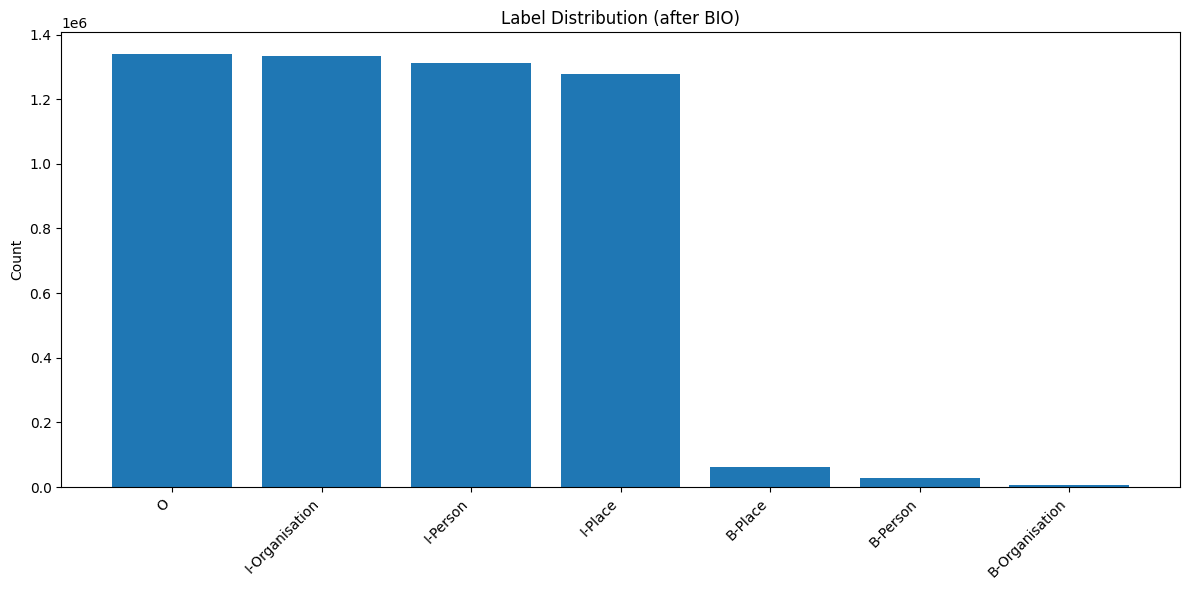


Class Weights (sample):
{'B-Organisation': 104.36519402636344, 'B-Person': 26.92525857348812, 'B-Place': 12.26419739527562, 'I-Organisation': 0.5745745273616055, 'I-Person': 0.5838188240870799, 'I-Place': 0.5993544303217148, 'O': 0.5714285714285714}


In [7]:
# Distribusi label & class weights
all_labels = [label for seq in sentence_labels for label in seq]
label_counts = Counter(all_labels)

print("Distribusi Label (top 30):")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:30]:
    print(f"{label}: {count} ({count/len(all_labels)*100:.4f}%)")

# Visualisasi
plt.figure(figsize=(12,6))
labels_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels_names = [l[0] for l in labels_sorted]
labels_values = [l[1] for l in labels_sorted]

plt.bar(range(len(labels_names)), labels_values)
plt.xticks(range(len(labels_names)), labels_names, rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Label Distribution (after BIO)')
plt.tight_layout()
plt.show()

# Class weights (dictionary keyed by label id) — sesuai kode awal
total_samples = len(all_labels)
class_weights = {}
num_classes = len(label_list)
for label in label_list:
    count = label_counts.get(label, 1)
    weight = total_samples / (num_classes * count)
    class_weights[label_to_id[label]] = float(weight)

print("\nClass Weights (sample):")
for lid, w in list(class_weights.items())[:20]:
    pass
print({id_to_label[k]: v for k, v in class_weights.items()})


Bagian ini mengecek seberapa seimbang atau timpang distribusi label di dataset, lalu menghitung class weights agar model tidak bias ke label mayoritas. Menghitung class weight: semakin langka sebuah label, semakin tinggi bobotnya. Dengan begitu, pelatihan jadi lebih adil dan model tidak berat sebelah terhadap label mayoritas.

# Tokenizer + fungsi align label (untuk subword tokenization)

In [8]:
# Tokenizer and label alignment
model_name = "ChristopherA08/IndoELECTRA"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding=False
    )

    aligned_labels = []
    for i, labels in enumerate(batch["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous = None
        label_ids_seq = []

        for w in word_ids:
            if w is None:
                label_ids_seq.append(-100)
            elif w != previous:
                label_ids_seq.append(labels[w])
            else:
                label_ids_seq.append(-100)
            previous = w

        aligned_labels.append(label_ids_seq)

    tokenized["labels"] = aligned_labels
    return tokenized

tokenized_datasets = dataset_dict.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=["tokens", "ner_tags"]
)

print(tokenized_datasets)


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/33500 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/8376 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 33500
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 8376
    })
})


Bagian ini adalah proses mengubah deretan kata (tokens) menjadi angka yang bisa dipahami model sekaligus menyelaraskan label NER ke subword tokenizer. Fungsi tokenize_and_align_labels() memastikan bahwa hanya subword pertama dari sebuah kata yang mendapat label, sedangkan subword berikutnya diberi -100 (artinya “jangan dihitung saat training”). Hasil mapping ini diterapkan ke seluruh dataset (map), menghasilkan dataset final dengan kolom input_ids, attention_mask, dan labels yang sudah rapi. 

# Load model, resize embedding, freeze/unfreeze parameter

In [9]:
# Load model & freeze all
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    label2id=label_to_id,
    id2label=id_to_label,
    ignore_mismatched_sizes=True
)

model.resize_token_embeddings(len(tokenizer))

for param in model.parameters():
    param.requires_grad = False


# === Unfreeze hanya classifier / MLP head ===
if hasattr(model, "classifier"):
    for param in model.classifier.parameters():
        param.requires_grad = True
else:
    try:
        for param in model.vocab_transform.parameters():
            param.requires_grad = True
    except:
        pass


# === Unfreeze hanya 2 layer terakhir encoder ===
num_layers = len(model.electra.encoder.layer)
for i in range(num_layers-2, num_layers):
    for param in model.electra.encoder.layer[i].parameters():
        param.requires_grad = True


# Print info
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Total params:", trainable + frozen)
print("Trainable params:", trainable)
print("Frozen params:", frozen)
print("Unfrozen layers: classifier + last 2 layers")
print(f"Layers index: {num_layers-2} & {num_layers-1}")


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of ElectraForTokenClassification were not initialized from the model checkpoint at ChristopherA08/IndoELECTRA and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Total params: 112336135
Trainable params: 14181127
Frozen params: 98155008
Unfrozen layers: classifier + last 2 layers
Layers index: 10 & 11


Dilakukan fine-tuning dengan cara membekukan seluruh parameter model dasar ELECTRA dan hanya membuka (unfreeze) lapisan klasifikasi serta dua lapisan encoder terakhir. Pendekatan ini merupakan strategi parameter-efficient fine-tuning yang bertujuan mempertahankan representasi bahasa yang telah dipelajari model secara luas pada pre-training ("ChristopherA08/IndoELECTRA"), sekaligus memungkinkan adaptasi terbatas pada domain atau tugas baru. Dengan hanya melatih sekitar 12–15% dari total parameter, model dapat beradaptasi terhadap pola spesifik Named Entity Recognition (NER) tanpa risiko catastrophic forgetting dan dengan biaya komputasi yang lebih rendah. Pesan mengenai initializer baru untuk classifier menunjukkan bahwa head klasifikasi dibentuk ulang karena jumlah label berbeda dari model asli, sehingga bagian tersebut harus dilatih dari awal.

# Data collator, metrics, WeightedTrainer (custom loss)

In [10]:
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is not None:
            self.class_weights = torch.tensor(
                [class_weights[i] for i in range(len(class_weights))],
                dtype=torch.float32
            ).to(self.args.device)
        else:
            self.class_weights = None

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None, 
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(
                weight=self.class_weights,
                ignore_index=-100
            )
            loss = loss_fct(
                logits.view(-1, logits.shape[-1]),
                labels.view(-1)
            )
        else:
            loss = outputs.loss

        if return_outputs:
            return (loss, outputs)

        return loss


Mmbuat Trainer khusus  WeightedTrainer yang berfungsi menambahkan class weighting ke dalam perhitungan loss untuk tugas NER. Digunakan untuk mengatasi class imbalance, yaitu kondisi ketika beberapa label muncul jauh lebih sedikit dibandingkan label lain. Dengan menambahkan bobot kelas, kesalahan pada kelas minoritas akan dihitung lebih besar, sehingga model terdorong untuk lebih memperhatikan label-label yang jarang muncul. Pada compute_loss, trainer menghitung manual cross-entropy loss dengan memasukkan class_weights dan tetap mengabaikan token dengan label -100 (masking hasil alignment). Jika bobot tidak diberikan, Trainer akan kembali menggunakan loss default dari HuggingFace. Pendekatan ini memungkinkan fine-tuning yang lebih stabil dan adil pada dataset NER yang tidak seimbang.

# Training arguments, early stopping, instantiate trainer, train

In [11]:
# Training arguments and trainer init
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./NER-IndoELECTRA",


    eval_strategy="epoch",     
    logging_strategy="epoch",         
    save_strategy="epoch",

    optim="adamw_torch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    gradient_accumulation_steps=4,
    num_train_epochs=12,
    fp16=True,

    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    logging_steps=100,
    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=3,
    report_to="none",

    max_grad_norm=1.0,
    lr_scheduler_type="cosine"
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

from seqeval.metrics import accuracy_score, f1_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=-1)

    true_predictions = [
        [label_list[pred] for pred, lab in zip(pred_row, lab_row) if lab != -100]
        for pred_row, lab_row in zip(predictions, labels)
    ]

    true_labels = [
        [label_list[lab] for pred, lab in zip(pred_row, lab_row) if lab != -100]
        for pred_row, lab_row in zip(predictions, labels)
    ]

    return {
        "accuracy": accuracy_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
    class_weights=class_weights
)

print("Trainer configured. Starting training...")
trainer.train()


/tmp/ipykernel_19/743058704.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Trainer configured. Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.017100,0.274192,0.945749,0.328248
2,0.244200,0.226387,0.949594,0.358844
3,0.210000,0.211127,0.955189,0.392314
4,0.193900,0.200889,0.953484,0.388175
5,0.181700,0.196853,0.953447,0.390492
6,0.172800,0.195889,0.955266,0.401133
7,0.165000,0.198434,0.957287,0.412577
8,0.159600,0.197749,0.955382,0.404934
9,0.155100,0.195467,0.957012,0.411357
10,0.152200,0.197353,0.957681,0.417092


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

TrainOutput(global_step=3144, training_loss=0.246084142883922, metrics={'train_runtime': 6546.6313, 'train_samples_per_second': 61.406, 'train_steps_per_second': 0.48, 'total_flos': 5.2185695377949496e+16, 'train_loss': 0.246084142883922, 'epoch': 12.0})

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Eval metrics: {'eval_loss': 0.19735288619995117, 'eval_accuracy': 0.9576812405269908, 'eval_f1': 0.417091890524185, 'eval_runtime': 81.2896, 'eval_samples_per_second': 103.039, 'eval_steps_per_second': 1.612, 'epoch': 12.0}


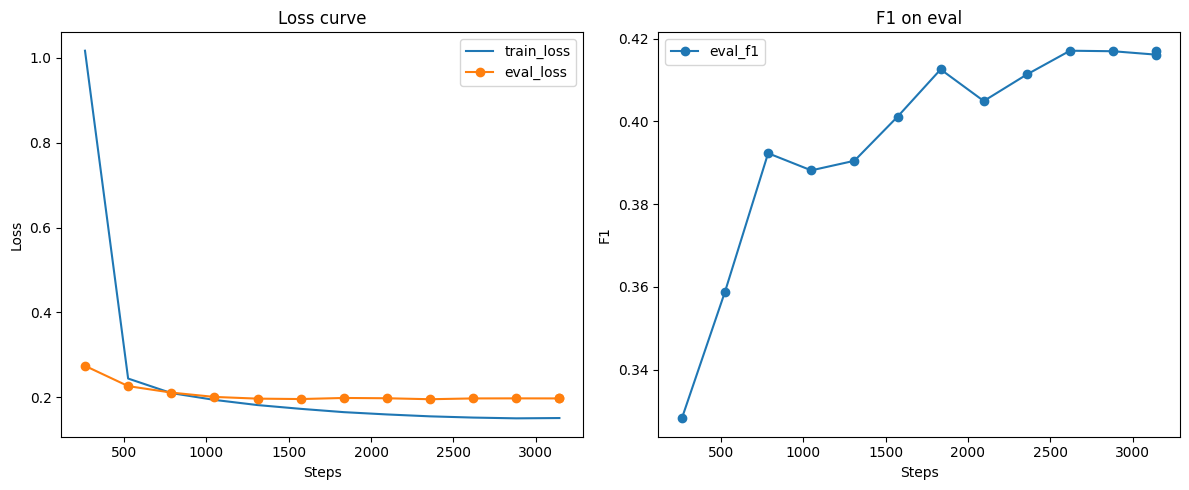

In [12]:
# Evaluation & training curves
metrics = trainer.evaluate()
print("Eval metrics:", metrics)

# Plot training history (loss)
log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []
eval_f1 = []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])
        if "eval_f1" in entry:
            eval_f1.append(entry["eval_f1"])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_steps, train_loss, label="train_loss")
plt.plot(eval_steps, eval_loss, label="eval_loss", marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curve")

plt.subplot(1,2,2)
if eval_f1:
    plt.plot(eval_steps, eval_f1, label="eval_f1", marker='o')
    plt.xlabel("Steps")
    plt.ylabel("F1")
    plt.title("F1 on eval")
    plt.legend()
else:
    plt.text(0.5, 0.5, "No eval F1 in log history", ha='center')

plt.tight_layout()
plt.show()


Kurva training menunjukkan bahwa train loss terus menurun secara stabil dari sekitar 1.0 menuju di bawah 0.2, menandakan bahwa model berhasil mempelajari pola dari data training dengan baik. Sementara itu, eval loss juga turun hingga stabil di sekitar 0.2, menunjukkan tidak ada tanda overfitting berat karena gap train–eval relatif kecil dan sama-sama menurun. Pada grafik F1, skor meningkat signifikan dari sekitar 0.33 hingga mendekati 0.417, lalu mulai konvergen, mencerminkan bahwa model semakin baik dalam mendeteksi label NER yang jarang sekalipun. Meski accuracy sangat tinggi (95%), skor F1 yang lebih rendah menggambarkan bahwa sebagian besar token adalah kelas "O", sehingga akurasi kurang representatif; F1 lebih cocok untuk menilai performa pada kelas minoritas. Secara keseluruhan, model menunjukkan learning curve yang baik, yaitu loss stabil, tidak overfitting, dan peningkatan F1 yang konsisten—walaupun hasil akhir masih dapat ditingkatkan dengan perbaikan label weighting, augmentasi teks, atau unfreezing layer yang lebih banyak.

# Evaluation (Belum FIXX)


=== SEQEVAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Organisation     0.1666    0.6428    0.2646      3074
      Person     0.1850    0.6341    0.2864      7177
       Place     0.3829    0.7945    0.5167     14654

   micro avg     0.2717    0.7295    0.3960     24905
   macro avg     0.2448    0.6905    0.3559     24905
weighted avg     0.2992    0.7295    0.4193     24905


=== MICRO / MACRO / WEIGHTED METRICS ===
Micro Precision:  0.9577
Micro Recall:     0.9577
Micro F1:         0.9577

Macro Precision:  0.6816
Macro Recall:     0.9391
Macro F1:         0.7259

Weighted Precision: 0.9857
Weighted Recall:    0.9577
Weighted F1:        0.9678


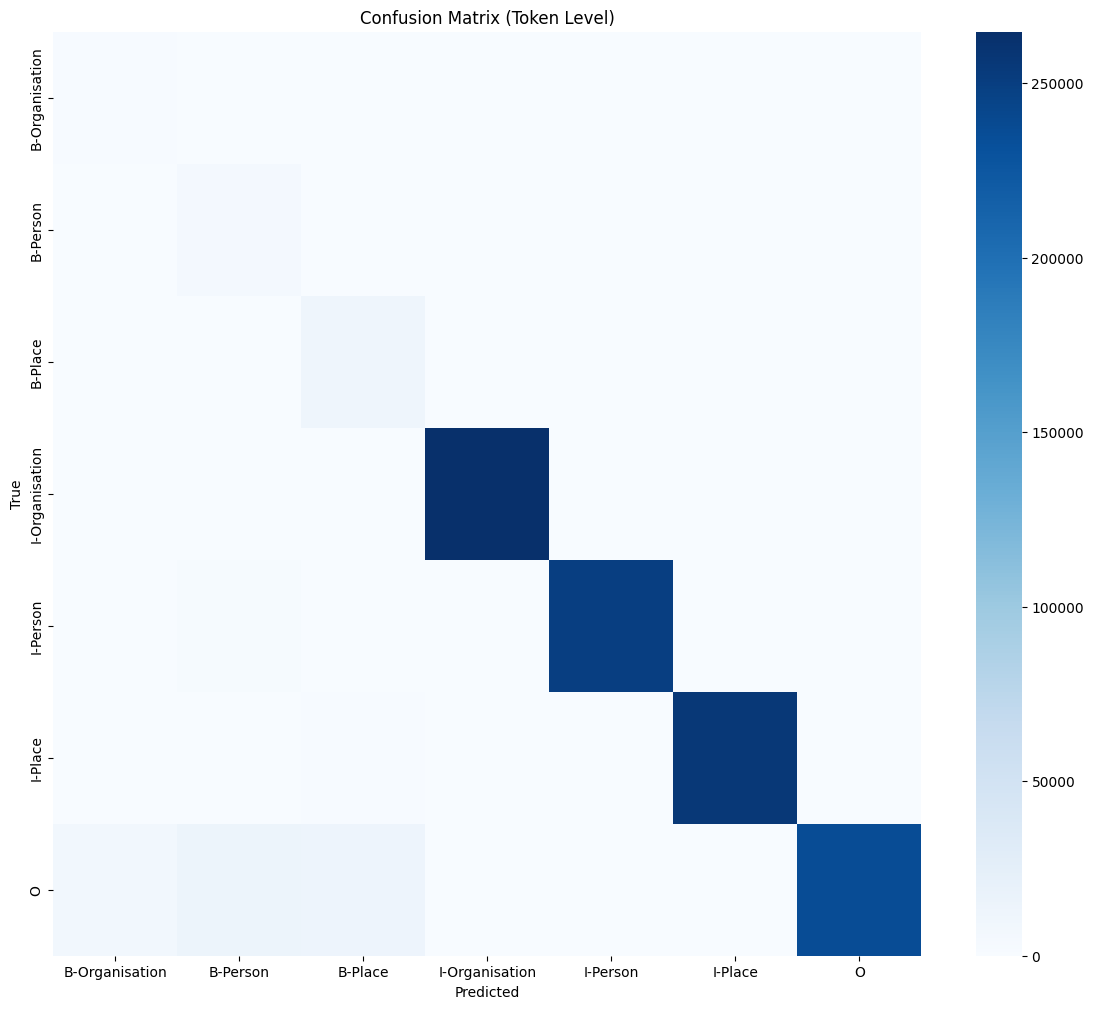


=== ROC–AUC (One-vs-Rest) ===
B-Organisation: 0.9935
B-Person: 0.9928
B-Place: 0.9903
I-Organisation: 0.9995
I-Person: 0.9988
I-Place: 0.9990
O: 0.9981

=== SUMMARY ===
Sequence-level metrics selesai dihitung.
Termasuk micro, macro, weighted average, confusion matrix, dan ROC–AUC per label.


In [13]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score
)
from seqeval.metrics import classification_report as seq_classification_report

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

id2label = {v: k for k, v in label_to_id.items()}

# Prediksi model pada validation set
predictions_output = trainer.predict(tokenized_datasets["validation"])
logits = predictions_output.predictions
true_labels = predictions_output.label_ids
pred_ids = np.argmax(logits, axis=-1)

# Pengambilan label valid (mengabaikan -100)
y_true, y_pred = [], []
for pred_row, lab_row in zip(pred_ids, true_labels):
    for p, l in zip(pred_row, lab_row):
        if l != -100:
            y_true.append(id2label[l])
            y_pred.append(id2label[p])

# Report berbasis BIO (seqeval)
print("\n=== SEQEVAL CLASSIFICATION REPORT ===")
print(seq_classification_report([y_true], [y_pred], digits=4))

# Micro, Macro, dan Weighted averaging
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="micro"
)
p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)
p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted"
)

print("\n=== MICRO / MACRO / WEIGHTED METRICS ===")
print(f"Micro Precision:  {p_micro:.4f}")
print(f"Micro Recall:     {r_micro:.4f}")
print(f"Micro F1:         {f_micro:.4f}\n")
print(f"Macro Precision:  {p_macro:.4f}")
print(f"Macro Recall:     {r_macro:.4f}")
print(f"Macro F1:         {f_macro:.4f}\n")
print(f"Weighted Precision: {p_weighted:.4f}")
print(f"Weighted Recall:    {r_weighted:.4f}")
print(f"Weighted F1:        {f_weighted:.4f}")

# Confusion Matrix
labels_sorted = sorted(label_list)
cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

plt.figure(figsize=(14,12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Confusion Matrix (Token Level)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC–AUC one-vs-rest
y_true_multi = []
for lab in y_true:
    vec = [0]*len(label_list)
    vec[label_to_id[lab]] = 1
    y_true_multi.append(vec)

y_true_multi = np.array(y_true_multi)

logits_filtered = []
for i, lab_row in enumerate(true_labels):
    for j, l in enumerate(lab_row):
        if l != -100:
            logits_filtered.append(logits[i][j])

logits_filtered = np.array(logits_filtered)

print("\n=== ROC–AUC (One-vs-Rest) ===")
roc_auc_scores = {}
for idx, label in enumerate(label_list):
    try:
        auc = roc_auc_score(
            y_true_multi[:, idx],
            logits_filtered[:, idx]
        )
        roc_auc_scores[label] = auc
        print(f"{label}: {auc:.4f}")
    except:
        print(f"{label}: tidak dapat dihitung (kelas tunggal).")

print("\n=== SUMMARY ===")
print("Sequence-level metrics selesai dihitung.")
print("Termasuk micro, macro, weighted average, confusion matrix, dan ROC–AUC per label.")
